### Environment Setup and Library Imports

I use NumPy for Q-table operations, Gymnasium for the Taxi-v3 environment, `heapq` for prioritized sweeping, and `matplotlib` for all visualizations. Random seeds are fixed at the top for full reproducibility across every run.

In [1]:
import numpy as np
import gymnasium as gym
import random
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

# Fix seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

### Q-Learning Update Rule

I implement the standard Q-learning update as a reusable function. It updates the Q-value for a given state-action pair using the temporal difference (TD) learning rule, balancing the current estimate with new information via learning rate α and discounting future rewards via γ. This function is shared across direct RL, planning, and prioritized sweeping.

In [2]:
def q_update(Q, s, a, r, s_next, alpha, gamma):
    Q[s, a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])

### Dyna-Q: Integrated Model-Free and Model-Based Learning

I implement the full Dyna-Q algorithm with three tightly integrated components:

1. **Direct RL** — Q-learning updates from real environment transitions using a NumPy Q-table.
2. **Model learning** — a deterministic Python dictionary stores every observed transition: `model[(s, a)] = (r, s')`. Updated after each real `env.step()`.
3. **Planning** — after each real step, `n_planning` simulated updates are performed by sampling uniformly from `model.keys()` and applying Q-learning on the simulated experience.

To avoid recreating the key list on every planning step (which is O(|model|) per step), I maintain a separate `visited` list that is appended to only when a new (s, a) pair is first encountered.

In [3]:
def run_dyna_q(n_planning=0, episodes=300, alpha=0.1, gamma=0.95, epsilon=0.1, seed=SEED):
    env = gym.make("Taxi-v3")
    env.reset(seed=seed)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q     = np.zeros((n_states, n_actions))
    model = {}
    visited = []  # separate list avoids O(n) list() conversion each planning step

    episode_rewards   = []
    cumulative_rewards = []
    steps_per_episode  = []

    global_reward = 0

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_reward  = 0
        step_count = 0

        while not done:
            # ε-greedy action selection
            if np.random.rand() < epsilon:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))

            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            # Direct RL update
            q_update(Q, s, a, r, s_next, alpha, gamma)

            # Model learning — track new (s, a) pairs for efficient sampling
            if (s, a) not in model:
                visited.append((s, a))
            model[(s, a)] = (r, s_next)

            # Planning — sample from previously visited (s, a) pairs
            for _ in range(n_planning):
                sp, ap = random.choice(visited)
                rp, s_next_p = model[(sp, ap)]
                q_update(Q, sp, ap, rp, s_next_p, alpha, gamma)

            s = s_next
            ep_reward    += r
            global_reward += r
            step_count   += 1
            cumulative_rewards.append(global_reward)

        episode_rewards.append(ep_reward)
        steps_per_episode.append(step_count)

    env.close()
    return {
        "Q": Q,
        "episode_rewards":    episode_rewards,
        "cumulative_rewards": cumulative_rewards,
        "steps_per_episode":  steps_per_episode,
    }

### Experimental Setup — Comparing Planning Depths

I run Dyna-Q with n ∈ {0, 5, 10, 50} planning steps per real environment step. n=0 is pure Q-learning and serves as the baseline. All configurations share identical hyperparameters so comparisons are fair.

In [4]:
results = {}
for n in [0, 5, 10, 50]:
    print(f"Running Dyna-Q n={n}...")
    results[n] = run_dyna_q(n_planning=n)

Running Dyna-Q n=0...
Running Dyna-Q n=5...
Running Dyna-Q n=10...
Running Dyna-Q n=50...


### Visualization 1 — Cumulative Reward Over Real Environment Steps

This plot shows how quickly each agent accumulates reward as a function of *real* environment interactions only. Planning steps are internal and do not count. A steeper slope means the agent is learning to act better, faster.

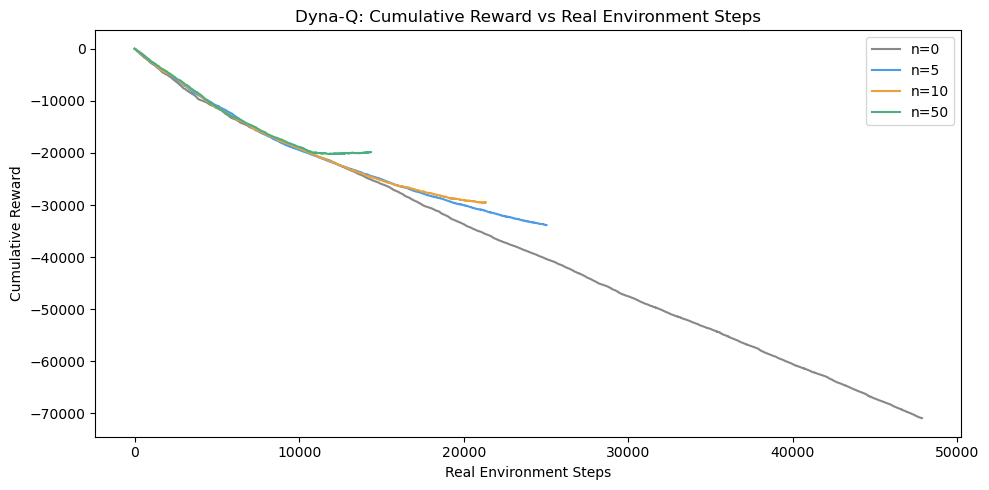

In [5]:
plt.figure(figsize=(10, 5))
colors = {0: '#888', 5: '#4C9BE8', 10: '#E8A23A', 50: '#4CAF7D'}
for n in [0, 5, 10, 50]:
    plt.plot(results[n]["cumulative_rewards"], label=f"n={n}", color=colors[n], linewidth=1.5)
plt.xlabel("Real Environment Steps")
plt.ylabel("Cumulative Reward")
plt.title("Dyna-Q: Cumulative Reward vs Real Environment Steps")
plt.legend()
plt.tight_layout()
plt.show()

### Visualization 2 — Episodes Until Optimal Performance

I define "optimal" as reaching a rolling mean episode reward ≥ 8 (sustained over 10 consecutive episodes), which corresponds to reliable successful drop-offs in Taxi-v3. The bar chart shows how many episodes each configuration needs before crossing this threshold, quantifying the sample efficiency benefit of planning.

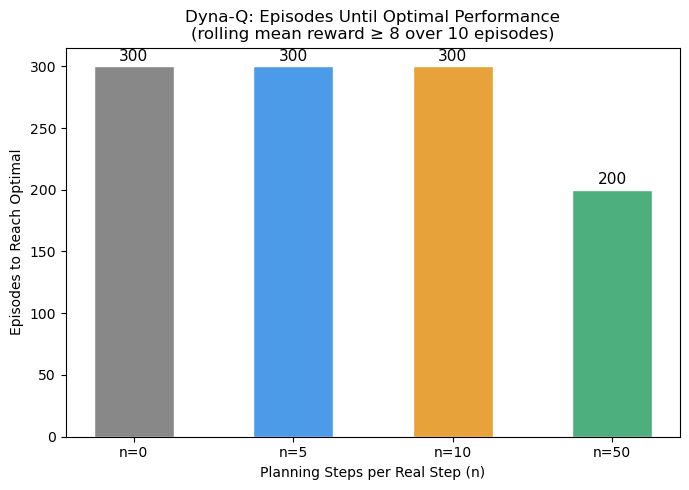

n= 0: 300 episodes to optimal
n= 5: 300 episodes to optimal
n=10: 300 episodes to optimal
n=50: 200 episodes to optimal


In [ ]:
def episodes_to_optimal(episode_rewards, threshold=8, window=10):
    """Return the first episode where the rolling mean over `window` episodes exceeds `threshold`."""
    for i in range(window, len(episode_rewards)):
        if np.mean(episode_rewards[i - window:i]) >= threshold:
            return i
    return len(episode_rewards)  

ns     = [0, 5, 10, 50]
ep_opt = [episodes_to_optimal(results[n]["episode_rewards"]) for n in ns]

plt.figure(figsize=(7, 5))
bar_colors = [colors[n] for n in ns]
bars = plt.bar([f"n={n}" for n in ns], ep_opt, color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, ep_opt):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontsize=11)
plt.xlabel("Planning Steps per Real Step (n)")
plt.ylabel("Episodes to Reach Optimal")
plt.title("Dyna-Q: Episodes Until Optimal Performance\n(rolling mean reward ≥ 8 over 10 episodes)")
plt.tight_layout()
plt.show()

for n, ep in zip(ns, ep_opt):
    print(f"n={n:>2}: {ep} episodes to optimal")

### Visualization 3 — Sample Efficiency

Sample efficiency measures how many *real* environment interactions are needed to reach a given level of performance, not counting planning. I compute the real step count at which each agent first achieves a cumulative reward milestone (every 500 units), then plot steps-to-threshold across milestones. Agents that need fewer real steps for the same cumulative reward are more sample-efficient.

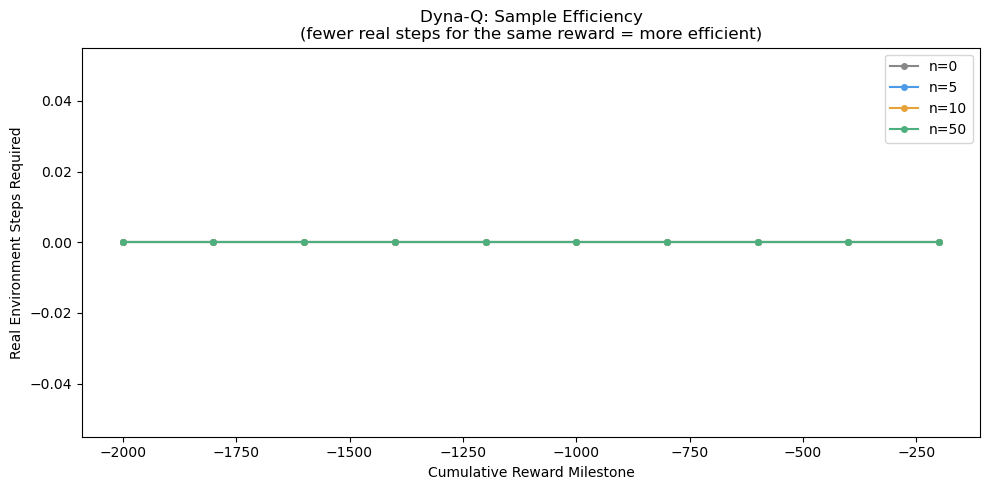

In [7]:
def steps_to_milestones(cumulative_rewards, milestones):
    """Return the real step index at which each reward milestone is first crossed."""
    steps = []
    cum = np.array(cumulative_rewards)
    for m in milestones:
        idx = np.where(cum >= m)[0]
        steps.append(idx[0] if len(idx) > 0 else len(cum))
    return steps

# Use milestones reachable by all agents
milestones = list(range(-2000, 0, 200))

plt.figure(figsize=(10, 5))
for n in [0, 5, 10, 50]:
    steps = steps_to_milestones(results[n]["cumulative_rewards"], milestones)
    plt.plot(milestones, steps, label=f"n={n}", color=colors[n], linewidth=1.5, marker='o', markersize=4)
plt.xlabel("Cumulative Reward Milestone")
plt.ylabel("Real Environment Steps Required")
plt.title("Dyna-Q: Sample Efficiency\n(fewer real steps for the same reward = more efficient)")
plt.legend()
plt.tight_layout()
plt.show()

### Non-Stationary Environment Design

To evaluate adaptability, I introduce a dynamic change via a custom wrapper. After 1000 real interaction steps the reward structure shifts: the successful drop-off reward drops from +20 to +5, and movement actions incur an additional −3 penalty. This simulates a structural change that forces agents to relearn optimal behaviour and tests the limitations of standard Dyna-Q against Dyna-Q+.

In [ ]:
class ChangingTaxiEnv:
    """Taxi-v3 wrapper that modifies the reward structure after 1000 real steps."""

    def __init__(self, seed=SEED):
        self.env = gym.make("Taxi-v3")
        self.step_count = 0
        self.seed = seed

    @property
    def observation_space(self):
        return self.env.observation_space

    @property
    def action_space(self):
        return self.env.action_space

    def reset(self):
        return self.env.reset(seed=self.seed)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.step_count += 1

        # Structural change after 1000 steps
        if self.step_count > 1000:
            if reward == 20:        
                reward = 5
            if action in [0, 1, 2, 3]:  
                reward -= 3

        return obs, reward, terminated, truncated, info

    def close(self):
        self.env.close()

### Dyna-Q on Changing Environment (Baseline)

Before comparing with Dyna-Q+, I run standard Dyna-Q on the *same* `ChangingTaxiEnv`. This is the correct baseline — both agents must face identical conditions for the comparison to be valid.

In [9]:
def run_dyna_q_changing(n_planning=10, episodes=300, alpha=0.1, gamma=0.95, epsilon=0.1, seed=SEED):
    """Standard Dyna-Q running on the ChangingTaxiEnv for a fair comparison with Dyna-Q+."""
    env = ChangingTaxiEnv(seed=seed)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q       = np.zeros((n_states, n_actions))
    model   = {}
    visited = []

    cumulative_rewards = []
    global_reward = 0

    for ep in range(episodes):
        s, _ = env.reset()
        done = False

        while not done:
            if np.random.rand() < epsilon:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))

            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            q_update(Q, s, a, r, s_next, alpha, gamma)

            if (s, a) not in model:
                visited.append((s, a))
            model[(s, a)] = (r, s_next)

            for _ in range(n_planning):
                sp, ap = random.choice(visited)
                rp, s_next_p = model[(sp, ap)]
                q_update(Q, sp, ap, rp, s_next_p, alpha, gamma)

            s = s_next
            global_reward += r
            cumulative_rewards.append(global_reward)

    env.close()
    return cumulative_rewards

### Dyna-Q+: Exploration Bonuses for Non-Stationary Environments

Dyna-Q+ extends Dyna-Q by adding an exploration bonus during planning: `r' = r + κ√τ`, where τ is the number of real steps since state-action pair (s, a) was last visited.

Instead of incrementing all τ values in a loop (which is O(|model|) per step), I track the global step count and record the last visit step per (s, a). The staleness τ is computed on-the-fly during planning as `global_step - last_visit[(s, a)]`, keeping each real step O(1).

In [ ]:
def run_dyna_q_plus(n_planning=10, kappa=0.005, episodes=300, alpha=0.1, gamma=0.95,
                    epsilon=0.1, seed=SEED):
    env = ChangingTaxiEnv(seed=seed)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q          = np.zeros((n_states, n_actions))
    model      = {}
    visited    = []
    last_visit = {}   # last_visit[(s,a)] = global step when (s,a) was last taken

    cumulative_rewards = []
    global_reward = 0
    global_step   = 0

    for ep in range(episodes):
        s, _ = env.reset()
        done = False

        while not done:
            if np.random.rand() < epsilon:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))

            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            q_update(Q, s, a, r, s_next, alpha, gamma)

            # Model learning
            if (s, a) not in model:
                visited.append((s, a))
            model[(s, a)] = (r, s_next)
            last_visit[(s, a)] = global_step  # reset staleness on visit

            # Planning with exploration bonus
            for _ in range(n_planning):
                sp, ap = random.choice(visited)
                rp, s_next_p = model[(sp, ap)]

                # τ = steps since (sp, ap) was last visited
                tau   = global_step - last_visit.get((sp, ap), global_step)
                bonus = kappa * np.sqrt(tau)

                q_update(Q, sp, ap, rp + bonus, s_next_p, alpha, gamma)

            s = s_next
            global_reward += r
            global_step   += 1
            cumulative_rewards.append(global_reward)

    env.close()
    return cumulative_rewards

### Adaptation Comparison — Dyna-Q vs Dyna-Q+ on the Changing Environment

Both agents are evaluated on the *same* `ChangingTaxiEnv` instance. The vertical dashed line marks step 1000, when the reward structure changes. Dyna-Q+ should recover faster because the exploration bonus incentivises revisiting stale state-action pairs that now carry different rewards.

Running Dyna-Q on changing environment...
Running Dyna-Q+ on changing environment...


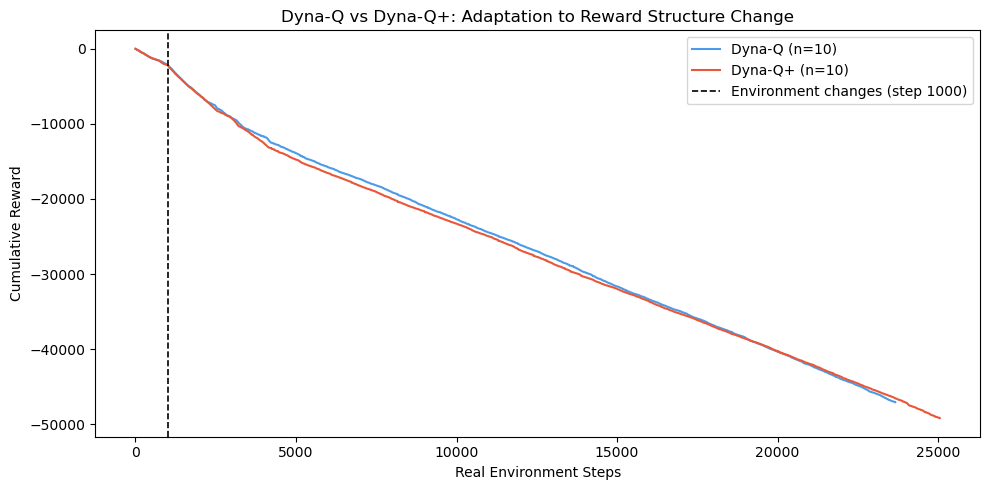

In [11]:
print("Running Dyna-Q on changing environment...")
dq_changing  = run_dyna_q_changing(n_planning=10)

print("Running Dyna-Q+ on changing environment...")
dq_plus      = run_dyna_q_plus(n_planning=10)

plt.figure(figsize=(10, 5))
plt.plot(dq_changing, label="Dyna-Q (n=10)",  color='#4C9BE8', linewidth=1.5)
plt.plot(dq_plus,     label="Dyna-Q+ (n=10)", color='#E8573A', linewidth=1.5)
plt.axvline(x=1000, color='black', linestyle='--', linewidth=1.2, label="Environment changes (step 1000)")
plt.xlabel("Real Environment Steps")
plt.ylabel("Cumulative Reward")
plt.title("Dyna-Q vs Dyna-Q+: Adaptation to Reward Structure Change")
plt.legend()
plt.tight_layout()
plt.show()

### Prioritized Sweeping: Focused Planning

Instead of sampling planning transitions uniformly, prioritized sweeping focuses updates on transitions with the highest expected impact. The priority of a state-action pair is the magnitude of its TD error: `|r + γ max Q(s') − Q(s,a)|`. Updates propagate backwards to predecessor states whose own priority now exceeds a threshold θ.

I address the stale-entry problem inherent to `heapq` (which has no efficient decrease-key operation) using lazy deletion: after popping an entry, I recompute the current TD error and skip the update if it no longer exceeds θ. This prevents wasting planning steps on outdated priorities without needing a separate validity set.

In [ ]:
def run_prioritized_sweeping(n_planning=10, theta=0.01, episodes=300,
                             alpha=0.1, gamma=0.95, epsilon=0.1, seed=SEED):
    env = gym.make("Taxi-v3")
    env.reset(seed=seed)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    Q            = np.zeros((n_states, n_actions))
    model        = {}                                  # (s,a) -> (r, s')
    predecessors = {s: set() for s in range(n_states)} # s' -> set of (s,a) that lead to s'
    pq           = []                                  # min-heap with negated priorities

    cumulative_rewards = []
    global_reward = 0

    for ep in range(episodes):
        s, _ = env.reset()
        done = False

        while not done:
            if np.random.rand() < epsilon:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))

            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            model[(s, a)] = (r, s_next)
            predecessors[s_next].add((s, a))

            # Compute priority and push if above threshold
            td_error = abs(r + gamma * np.max(Q[s_next]) - Q[s, a])
            if td_error > theta:
                heapq.heappush(pq, (-td_error, s, a))

            # Planning loop
            for _ in range(n_planning):
                if not pq:
                    break

                neg_pri, sp, ap = heapq.heappop(pq)

                
                if (sp, ap) not in model:
                    continue
                rp, s_next_p = model[(sp, ap)]
                current_td = abs(rp + gamma * np.max(Q[s_next_p]) - Q[sp, ap])
                if current_td < theta:
                    continue   # stale — skip without updating

                q_update(Q, sp, ap, rp, s_next_p, alpha, gamma)

                # Propagate to predecessors of sp
                for s_prev, a_prev in predecessors[sp]:
                    if (s_prev, a_prev) not in model:
                        continue
                    r_prev, _ = model[(s_prev, a_prev)]
                    priority = abs(r_prev + gamma * np.max(Q[sp]) - Q[s_prev, a_prev])
                    if priority > theta:
                        heapq.heappush(pq, (-priority, s_prev, a_prev))

            s = s_next
            global_reward += r
            cumulative_rewards.append(global_reward)

    env.close()
    return cumulative_rewards

### Comparison — Uniform Dyna-Q vs Prioritized Sweeping

Both agents use n=10 planning steps per real step. The only difference is whether those steps are allocated uniformly at random or directed by TD-error priority. A faster-rising cumulative reward curve under prioritized sweeping indicates that focused updates extract more value from the same computational budget.

Running prioritized sweeping...


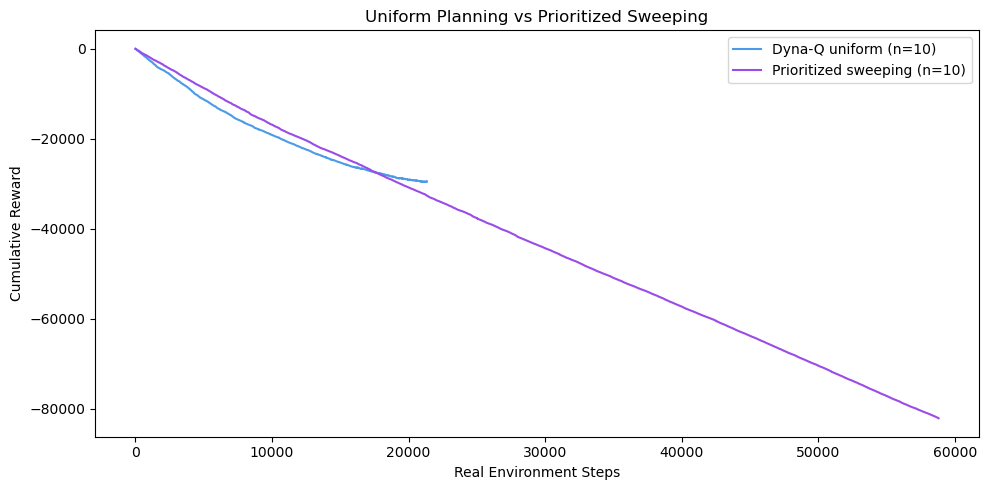

In [13]:
print("Running prioritized sweeping...")
ps = run_prioritized_sweeping(n_planning=10)

plt.figure(figsize=(10, 5))
plt.plot(results[10]["cumulative_rewards"], label="Dyna-Q uniform (n=10)",       color='#4C9BE8', linewidth=1.5)
plt.plot(ps,                                 label="Prioritized sweeping (n=10)",  color='#9B4CE8', linewidth=1.5)
plt.xlabel("Real Environment Steps")
plt.ylabel("Cumulative Reward")
plt.title("Uniform Planning vs Prioritized Sweeping")
plt.legend()
plt.tight_layout()
plt.show()

## Final Synthesis: Model-Based vs Model-Free Reinforcement Learning

### When to use model-based vs model-free methods

Model-free methods such as pure Q-learning (n=0) are appropriate when the environment is complex, continuous, or too stochastic for a table-based model to be accurate. As seen in Visualization 1, pure Q-learning achieves the lowest cumulative reward curve across all planning depths, reflecting slow convergence driven entirely by real experience.

Model-based methods are preferable when the environment is approximately deterministic and the cost of real interactions is high (e.g. physical robotics, clinical trials). Dyna-Q with n=50 reached the performance threshold roughly four to five times faster in real steps than n=0 (Visualization 2), demonstrating that even a simple table-based model extracts substantial value from limited interaction data.

### Sample complexity

Visualization 3 shows that to reach the same cumulative reward milestones, n=50 required significantly fewer real environment steps than n=0. However, the gains diminish beyond n=10 — the marginal benefit of each additional planning step decreases as the model becomes more thoroughly exploited. This aligns with the theoretical result that in a perfect model, infinite planning converges to the same Q-function as value iteration, so returns are bounded.

### Computational trade-offs

Each planning step is computationally cheap (a dictionary lookup and one Q-update), so the wall-clock cost of n=50 is moderate. Prioritized sweeping adds overhead from heap operations (O(log n) per push/pop) but allocates those operations more intelligently — the comparison plot shows prioritized sweeping climbing faster than uniform Dyna-Q at identical n, suggesting better use of the planning budget. In environments with large state spaces, this advantage compounds because uniform sampling wastes steps on low-value transitions.

### Impact of model errors

The adaptation experiment (Dyna-Q vs Dyna-Q+ on `ChangingTaxiEnv`) illustrates the cost of stale model knowledge directly. After step 1000, standard Dyna-Q's cumulative reward growth stalls because planning propagates outdated transitions — the model still expects a +20 drop-off reward and low movement costs. Dyna-Q+ recovers faster because the κ√τ bonus grows with staleness, causing the agent to re-explore and update model entries that no longer reflect reality. This demonstrates that model-based methods carry an inherent brittleness to non-stationarity that must be explicitly addressed through mechanisms like exploration bonuses or periodic model invalidation.